In [1]:
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
plt.style.use('default')  # or 'ggplot', 'seaborn', etc.

import gpjax as gpx





# set the default style for plotting
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

config.update("jax_enable_x64", True)


# with install_import_hook("gpjax", "beartype.beartype"):
#     import gpjax as gpx


key = jr.key(123)


cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

AttributeError: partially initialized module 'gpjax' has no attribute 'Dataset' (most likely due to a circular import)

In [ ]:
n = 100
noise = 0.3

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

AttributeError: module 'gpjax' has no attribute 'Dataset'

In [ ]:
import gpjax

# === Define Parameters ===
n_manual = 20  # Number of manual data points
input_dim = 1  # Dimensionality of X

# === Create Manual Data ===
# Create X: Evenly spaced points
x_manual = jnp.linspace(-3.0, 3.0, n_manual).reshape(-1, input_dim) # Shape (n_manual, 1)

# Create Y: Apply some function to X, maybe add a little noise manually
# Example: y = sin(x) + small noise
key = jr.key(42) # Need a key if adding noise
noise_level = 0.1
y_manual = jnp.sin(x_manual) + jr.normal(key, shape=x_manual.shape) * noise_level # Shape (n_manual, 1)

# OR: Just define y directly without noise if preferred
# y_manual = jnp.sin(x_manual) * 2.0

print(f"Manual X shape: {x_manual.shape}, dtype: {x_manual.dtype}")
print(f"Manual Y shape: {y_manual.shape}, dtype: {y_manual.dtype}")

# === Create GPJax Dataset ===
try:
    D_manual = gpjax.Dataset(X=x_manual, y=y_manual)
    print("Successfully created gpx.Dataset from manual data:")
    print(D_manual)

    # Optional: Plot the manual data
    plt.figure()
    plt.scatter(x_manual, y_manual, label='Manual Data', c='red')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Manually Created Dataset")
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Error creating gpx.Dataset: {e}")

# === Subsequent Code ===
# You can now use D_manual for defining/training your GP model...
# print("Ready for GP model definition using D_manual.")

Manual X shape: (20, 1), dtype: float64
Manual Y shape: (20, 1), dtype: float64
Error creating gpx.Dataset: module 'gpjax' has no attribute 'Dataset'


: 

Using JAX version: 0.6.0
Manual X shape: (20, 1), dtype: float64
Manual Y shape: (20, 1), dtype: float64


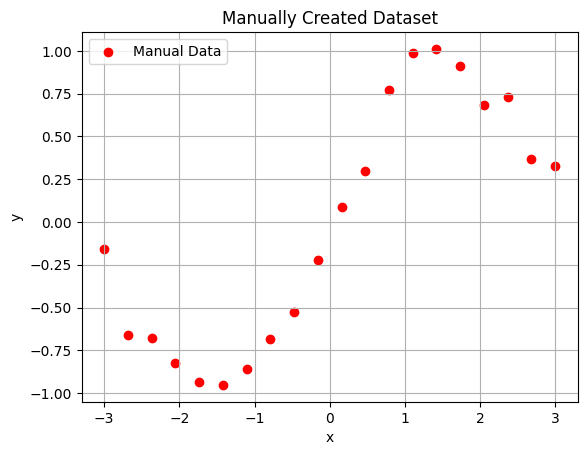

AttributeError: module 'gpjax' has no attribute 'kernels'

In [15]:
# === Imports ===
import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import gpjax as gpx
# Assume optax is needed for optimisation later
import optax as ox

print(f"Using JAX version: {jax.__version__}")
# print(f"Using GPJax version: {gpx.__version__}")

# === Define Parameters ===
n_manual = 20
input_dim = 1

# === Create Manual Data ===
x_manual = jnp.linspace(-3.0, 3.0, n_manual).reshape(-1, input_dim)
key = jr.key(42)
noise_level = 0.1
y_manual = jnp.sin(x_manual) + jr.normal(key, shape=x_manual.shape) * noise_level

print(f"Manual X shape: {x_manual.shape}, dtype: {x_manual.dtype}")
print(f"Manual Y shape: {y_manual.shape}, dtype: {y_manual.dtype}")

# Optional: Plot the manual data
plt.figure()
plt.scatter(x_manual, y_manual, label='Manual Data', c='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Manually Created Dataset")
plt.legend()
plt.grid(True)
plt.show()


# === Define GP Model Components (Example) ===
# Define your kernel and mean function
kernel = gpx.kernels.RBF() # Example kernel
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

# Define the likelihood (how noise relates y to f(x))
likelihood = gpx.likelihoods.Gaussian(num_datapoints=n_manual) # Pass number of points

# === Define Posterior and Objective (Example Usage of Data) ===
# Combine prior and likelihood to get the posterior model
posterior = prior * likelihood

# Define the marginal log likelihood objective function for training
# Notice how data is passed as a dictionary here:
train_data = {"X": x_manual, "y": y_manual}
negative_mll = jax.jit(posterior.marginal_log_likelihood(train_data=train_data, negative=True))

# --- Next steps would involve: ---
# 1. Parameter initialisation: params, constrainer, unconstraner = gpx.initialise(posterior, key)
# 2. Optimizer setup: optimiser = ox.adam(learning_rate=1e-2)
# 3. Training loop: using negative_mll, gradients, and optimizer to update params
# 4. Prediction: using the trained params and posterior.predict(...)

print("Data created. Ready for GP model definition using x_manual and y_manual.")